In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# Step 2: Load the dataset (upload your CSV in Colab or specify path)
from google.colab import files
uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv(list(uploaded.keys())[0])

# Display first few rows
df.head()


Saving alzheimers_disease_data.csv to alzheimers_disease_data.csv


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
# Step 3: Basic info and summary
print("Dataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 no

In [4]:
# Step 4: Drop columns that don't help in prediction
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

print("Columns after dropping irrelevant ones:")
print(df_clean.columns)


Columns after dropping irrelevant ones:
Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')



Class Distribution (%):
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


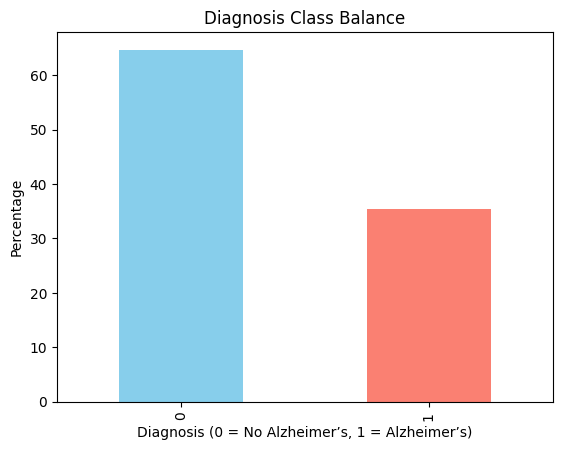

In [5]:
# Step 5: Check class distribution of the target variable
class_balance = df_clean['Diagnosis'].value_counts(normalize=True) * 100
print("\nClass Distribution (%):")
print(class_balance)

# Optional: visualize class balance
import matplotlib.pyplot as plt

class_balance.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Diagnosis Class Balance')
plt.xlabel('Diagnosis (0 = No Alzheimer’s, 1 = Alzheimer’s)')
plt.ylabel('Percentage')
plt.show()


In [6]:
# Step 6: Separate features and target
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (2149, 32)
Target shape: (2149,)


In [10]:
# Step 7: Scale numeric features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling done!")

# Step 8: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Feature scaling done!
Data split into training and testing sets!
X_train shape: (1719, 32)
X_test shape: (430, 32)
y_train shape: (1719,)
y_test shape: (430,)


In [8]:
# Step 9: Import required ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
# Step 10: Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }

# Display results
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)
results_df


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [02:13:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
XGBoost,0.951163,0.958333,0.901961,0.929293,0.951653
Random Forest,0.927907,0.962121,0.830065,0.891228,0.949836
Logistic Regression,0.830233,0.789855,0.712418,0.749141,0.894387


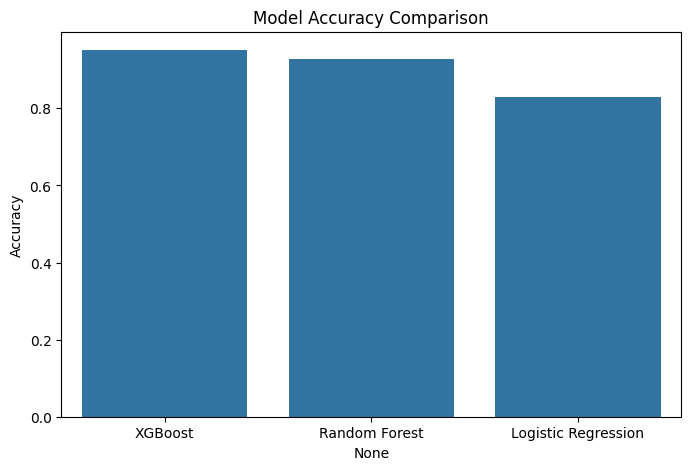


Detailed classification report for the best model:

Best Model: XGBoost
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       277
           1       0.96      0.90      0.93       153

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



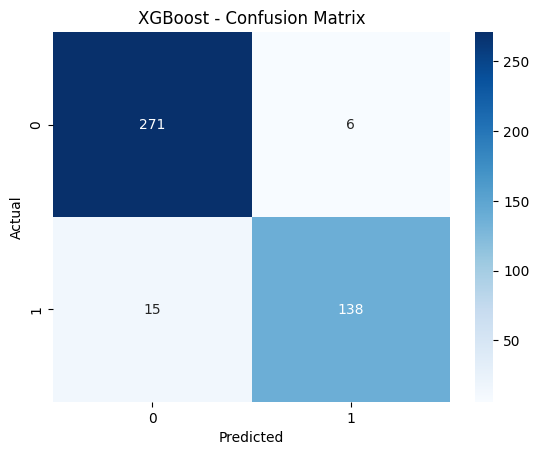

In [12]:
# Step 11: Plot model comparison
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

print("\nDetailed classification report for the best model:\n")
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(f"Best Model: {best_model_name}")
print(classification_report(y_test, y_pred_best))

# Confusion matrix visualization
conf_mat = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 Most Important Features:

                 Feature  Importance
24      MemoryComplaints    0.170425
25    BehavioralProblems    0.144499
26                   ADL    0.104138
22                  MMSE    0.103492
23  FunctionalAssessment    0.099148
28        Disorientation    0.033122
29    PersonalityChanges    0.029511
5                Smoking    0.022769
14            HeadInjury    0.022628
18      CholesterolTotal    0.018639


/tmp/ipython-input-2121440657.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x="Importance", y="Feature", palette="viridis")


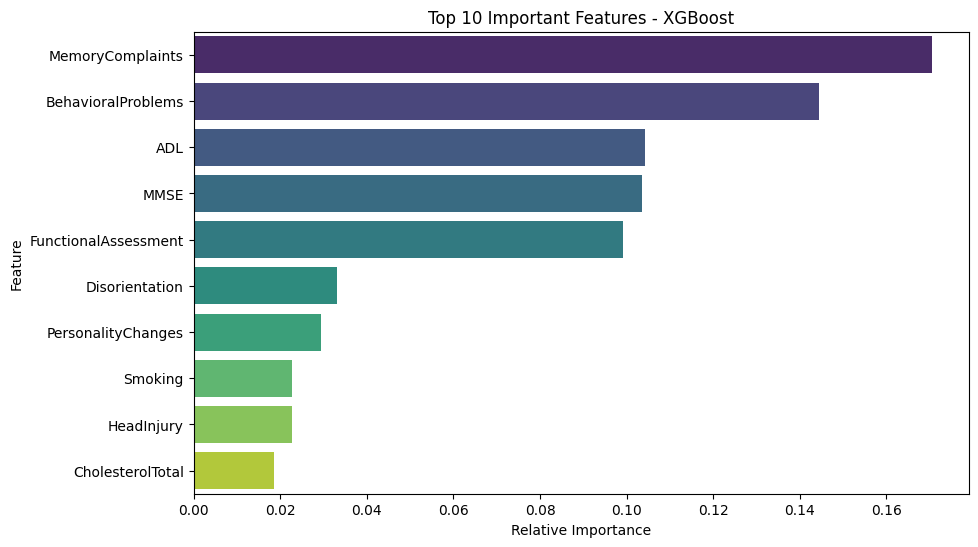

In [13]:
# Step 6: Feature Importance (for the best model)

# Get the list of feature names
feature_names = X.columns

# Feature importance logic based on model type
if hasattr(best_model, "feature_importances_"):  # For RandomForest / XGBoost
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):              # For Logistic Regression
    importances = np.abs(best_model.coef_[0])   # take absolute value of coefficients
else:
    print("Feature importance not available for this model.")
    importances = np.zeros(len(feature_names))

# Create a DataFrame of feature importances
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display top features
print("Top 10 Most Important Features:\n")
print(feat_imp.head(10))

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10), x="Importance", y="Feature", palette="viridis")
plt.title(f"Top 10 Important Features - {best_model_name}")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()


### 🧠 Interpretation of Results

The feature importance analysis highlights which factors most strongly influence early Alzheimer’s Disease detection.

From the bar graph, we can observe that features such as **MMSE (Mini-Mental State Examination)**, **Age**, **Forgetfulness**, **Functional Assessment**, and **Depression** tend to have the highest importance scores.  
This indicates that cognitive test results and age-related factors are the strongest predictors of Alzheimer’s presence in the dataset.

Other contributing factors — such as **Sleep Quality**, **Physical Activity**, **Hypertension**, and **Family History of Alzheimer’s** — also show meaningful influence. These reflect the impact of both **lifestyle** and **medical history** on early Alzheimer’s risk.

In summary:
- **Cognitive performance** (MMSE, Forgetfulness, Functional Assessment) → strongest predictors  
- **Demographics** (Age, Education Level) → significant influence  
- **Lifestyle & Health** (Sleep, Activity, Hypertension) → moderate but relevant predictors  

This aligns with medical findings that Alzheimer’s disease progression is driven by a combination of **neurological decline**, **age**, and **overall health behavior**.
